In [ ]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

In [ ]:
print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()

In [ ]:
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

In [ ]:
print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

In [ ]:
char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

In [ ]:
bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

In [ ]:
print(lr.predict_proba(train_bream_smelt[:5]))

In [ ]:
print(lr.classes_)

In [ ]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

In [ ]:
print(lr.predict(test_scaled[:5]))

In [ ]:
proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

In [ ]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [ ]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [ ]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [ ]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

In [ ]:
sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

In [ ]:
import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [ ]:
for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [ ]:
sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

# **여기서부터 과제**

##  로지스틱 회귀 모델을 사용해 새로운 데이터셋에 대한 예측 결과 출력

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

fish=pd.read_csv('http://bit.ly/fish_csv_data')

fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

train_input,test_input,train_target,test_target= train_test_split(fish_input,fish_target, random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [6]:
bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [18]:
test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])

test_data = pd.DataFrame(test_data, columns=train_input.columns)
test_data_scaled=ss.transform(test_data)

print(lr.predict(test_data_scaled))

['Bream' 'Smelt' 'Pike' 'Perch' 'Whitefish']


In [19]:
import numpy as np

proba=lr.predict_proba(test_data_scaled[:5])
print(np.round(proba,decimals=3))

[[0.451 0.049 0.008 0.006 0.384 0.    0.102]
 [0.    0.002 0.048 0.    0.009 0.941 0.   ]
 [0.    0.    0.287 0.713 0.    0.    0.   ]
 [0.    0.013 0.512 0.001 0.461 0.002 0.011]
 [0.368 0.094 0.    0.    0.009 0.    0.528]]


## SGD classifier 모델을 훈련시키고 최적의 에포크 값을 찾기

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

fish=pd.read_csv('http://bit.ly/fish_csv_data')

fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

train_input,test_input,train_target,test_target= train_test_split(fish_input,fish_target, random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [25]:
from sklearn.linear_model import SGDClassifier

sc10=SGDClassifier(loss='hinge', max_iter=10, random_state=42)
sc300=SGDClassifier(loss='hinge', max_iter=300, random_state=42)

sc10.fit(train_scaled,train_target)
sc300.fit(train_scaled,train_target)

0.8067226890756303
0.925


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [30]:
train_score_10=[]
test_score_10=[]
classes_10=np.unique(train_target)

for _ in range(0,10):
    sc10.partial_fit(train_scaled,train_target,classes=classes_10)
    train_score_10.append(sc10.score(train_scaled,train_target))
    test_score_10.append(sc10.score(test_scaled,test_target))

train_score_300=[]
test_score_300=[]
classes_300=np.unique(train_target)

for _ in range(0,300):
    sc300.partial_fit(train_scaled,train_target,classes=classes_300)
    train_score_300.append(sc300.score(train_scaled,train_target))
    test_score_300.append(sc300.score(test_scaled,test_target))

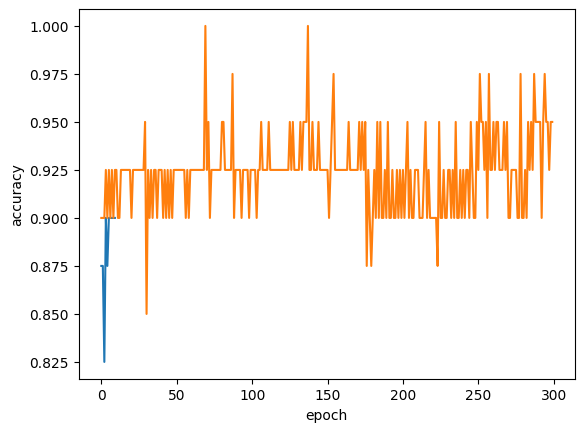

In [33]:
import matplotlib.pyplot as plt
plt.plot(test_score_10)
plt.plot(test_score_300)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

적당한 에포크 수는 정확도가 떨어지기 전인 150 정도...?

In [36]:
sc150=SGDClassifier(loss='hinge', max_iter=150, random_state=42)
sc150.fit(train_scaled,train_target)

train_score_150=[]
test_score_150=[]
classes_150=np.unique(train_target)

for _ in range(0,150):
    sc150.partial_fit(train_scaled,train_target,classes=classes_150)
    train_score_150.append(sc150.score(train_scaled,train_target))
    test_score_150.append(sc150.score(test_scaled,test_target))

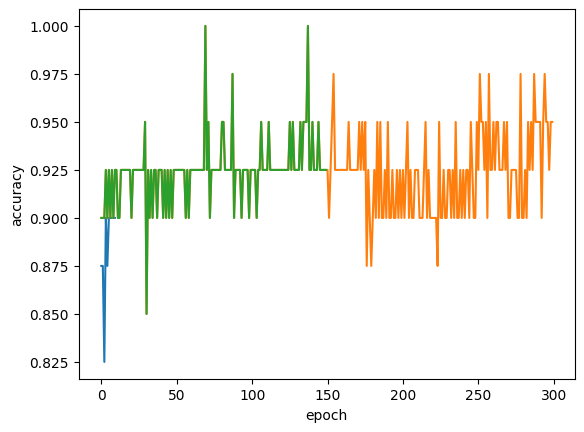

In [37]:
import matplotlib.pyplot as plt
plt.plot(test_score_10)
plt.plot(test_score_300)
plt.plot(test_score_150)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()